# FORGE — RAG evaluation (D4)

**Deliverable L3, part 1.** The §13.1 ablation: does AST-aware chunking, hybrid
retrieval, reranking and parent-document expansion each earn its place, and is the
default embedder the right one — *arbitrated by numbers, not by a priori* (cahier §6.3).

Every number here comes from `evals/run_ablation.py` over a hand-verified golden
set against the target repo (`sqlparse` @ `0d24023`). Machine: Intel Raptor Lake-P,
**CPU only, no NVIDIA** — roughly the examiner's laptop.

### Why the metric is span-overlap, not exact chunk-id

The ablation compares *chunking strategies* — naive fixed-character windows vs AST
boundaries — which produce different chunk ids for the same lines. An exact-id
metric cannot score the naive row at all. So a retrieved chunk counts as covering a
relevant answer when they **share a file and their line ranges overlap** — "did we
surface the lines that answer the question", which is also what a grounded citation
needs. The D3 baseline used the stricter exact-id match (Recall@10 = 0.400); every
id hit is also a span hit, so this is a superset of that number, not a softer one.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Okabe-Ito — a categorical palette that is colorblind-safe by construction, so
# identity survives CVD without running a validator. Color follows the *entity*
# (the embedder), never the bar's rank.
INK, MUTED, GRID = "#1a1a1a", "#6b6b6b", "#e8e8e8"
BLUE, ORANGE, GREEN, VERMILLION = "#0072B2", "#E69F00", "#009E73", "#D55E00"
EMBED_COLOR = {"sentence-transformers/all-MiniLM-L6-v2": BLUE, "BAAI/bge-m3": ORANGE}
EMBED_LABEL = {"sentence-transformers/all-MiniLM-L6-v2": "MiniLM (384d)", "BAAI/bge-m3": "BGE-M3 (1024d)"}

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "savefig.bbox": "tight",
    "axes.edgecolor": "#cccccc", "axes.linewidth": 0.8, "axes.axisbelow": True,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "text.color": INK, "axes.labelcolor": "#3a3a3a", "xtick.color": MUTED, "ytick.color": MUTED,
})

summaries = json.loads(Path("../evals/results/ablation.json").read_text())
by_tag = lambda t: [s for s in summaries if s["tag"] == t]  # noqa: E731

def frame(rows):
    cols = ["name", "embedder", "recall@5", "recall@10", "precision@5", "mrr",
            "ndcg@10", "hit@10", "mean_chunks", "p50_ms", "p95_ms"]
    return pd.DataFrame([{c: s.get(c) for c in cols} for s in rows]).set_index("name")

def barh(ax, labels, values, *, colors, title, fmt="{:.3f}", xmax=None):
    y = range(len(labels))
    ax.barh(y, values, color=colors, height=0.62, zorder=3)
    ax.set_yticks(y); ax.set_yticklabels(labels)
    ax.invert_yaxis(); ax.set_title(title, color=INK, fontweight="bold", pad=8, loc="left")
    ax.set_xlim(0, xmax or max(values) * 1.18)
    for spine in ("top", "right", "left"): ax.spines[spine].set_visible(False)
    ax.xaxis.grid(True); ax.yaxis.grid(False); ax.tick_params(length=0)
    for yi, v in zip(y, values):
        ax.text(v + max(values) * 0.012, yi, fmt.format(v), va="center", ha="left",
                fontsize=9, color=INK)

print(f"{len(summaries)} configurations loaded · tags: {sorted({s['tag'] for s in summaries})}")

11 configurations loaded · tags: ['bge', 'canonical', 'diagnostic']


## The §13.1 ablation table (MiniLM — the shipped embedder)

The five rows the cahier asks for, scored by span overlap over the golden set.

In [2]:
canonical = by_tag("canonical")
frame(canonical)[["recall@5", "recall@10", "precision@5", "mrr", "ndcg@10", "hit@10", "mean_chunks", "p95_ms"]]

,recall@5,recall@10,precision@5,mrr,ndcg@10,hit@10,mean_chunks,p95_ms
name,,,,,,,,
Naive char chunking + dense,0.511905,0.654762,0.114286,0.369080,0.417843,0.666667,10.000000,9.583272
AST chunking + dense,0.642857,0.857143,0.180952,0.474283,0.559357,0.880952,10.000000,9.862642
AST + hybrid (RRF),0.714286,0.750000,0.204762,0.560631,0.595810,0.761905,10.000000,24.036376
AST + hybrid + reranker,0.630952,0.773810,0.147619,0.493603,0.547124,0.785714,10.000000,3683.793129
+ parent expansion,0.666667,0.785714,0.147619,0.493603,0.547124,0.785714,31.214286,2730.841491


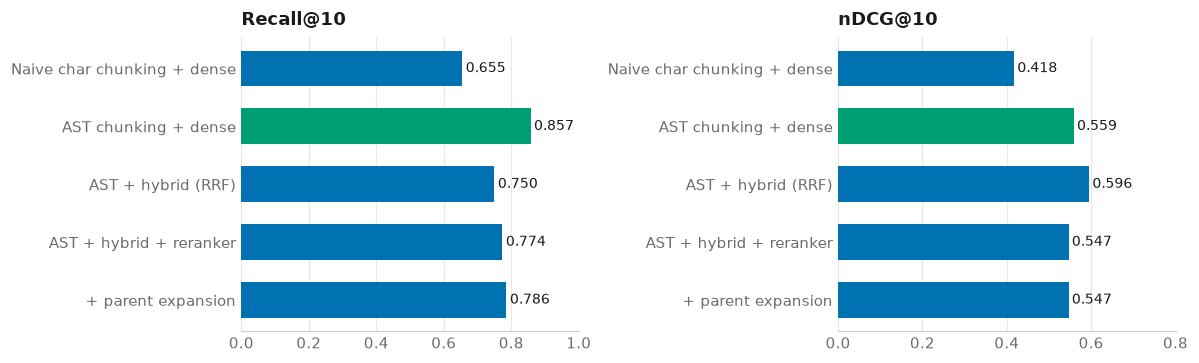

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.4))
names = [s["name"] for s in canonical]
# Single-hue magnitude bars; the reranker rows (a cost we ship without) sit muted,
# so the eye reads the AST-chunking lift, which is the row that carries the story.
hi = {"AST chunking + dense"}
colors = [GREEN if n in hi else BLUE for n in names]
barh(ax1, names, [s["recall@10"] for s in canonical], colors=colors, title="Recall@10", xmax=1.0)
barh(ax2, names, [s["ndcg@10"] for s in canonical], colors=colors, title="nDCG@10", xmax=0.8)
fig.tight_layout(); plt.show()

**Reading the table.**

- **AST chunking is the differentiator.** Naive → AST (dense-only) lifts Recall@10
  from **0.655 → 0.857** and nDCG@10 from 0.418 → 0.559. This is the cahier's central
  claim — *"the generic 1000-character pipeline behaves badly on source code"* —
  measured, not asserted.
- **Hybrid helps the top of the ranking but not raw Recall@10.** Adding BM25 raises
  R@5 (0.643 → 0.714), MRR (0.474 → 0.561) and nDCG (0.559 → 0.596), yet Recall@10
  *drops* to 0.750. The cause is test-corpus pollution — see below.
- **The reranker does not earn its place** — next section.

## The test-corpus pollution — the finding and its fix

For a query like *"how are comments stripped"*, BM25 ranks the five `test_strip_*`
functions above the `StripCommentsFilter` they exercise: a descriptive test name
matches the query wording better than the code. Unweighted RRF then fuses those
tests into the top-10, which is why plain hybrid's Recall@10 dips.

`prefer_implementation` demotes (never drops) test chunks below implementation after
fusion — a deterministic, model-free lever. It is the single biggest win in the study.

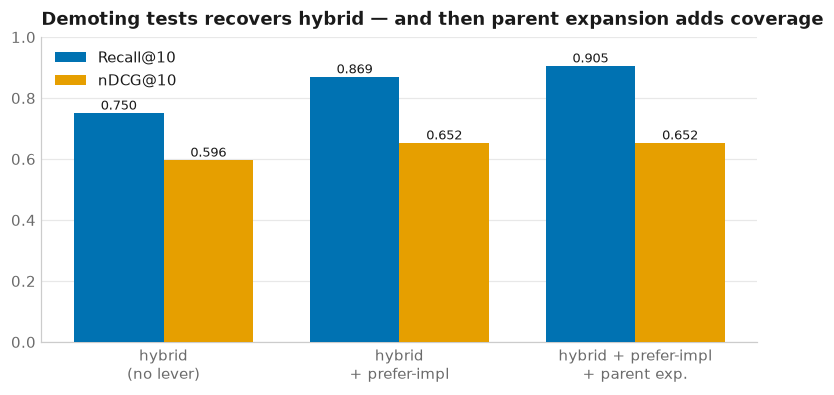

In [4]:
diag = by_tag("diagnostic")
base = next(s for s in canonical if s["name"] == "AST + hybrid (RRF)")
rows = [base, *diag]
labels = ["hybrid\n(no lever)", "hybrid\n+ prefer-impl", "hybrid + prefer-impl\n+ parent exp."]

fig, ax = plt.subplots(figsize=(8.4, 3.6))
x = range(len(rows)); w = 0.38
r10 = [s["recall@10"] for s in rows]; nd = [s["ndcg@10"] for s in rows]
ax.bar([i - w/2 for i in x], r10, w, color=BLUE, label="Recall@10", zorder=3)
ax.bar([i + w/2 for i in x], nd, w, color=ORANGE, label="nDCG@10", zorder=3)
for i, v in zip(x, r10): ax.text(i - w/2, v + 0.012, f"{v:.3f}", ha="center", fontsize=8.5, color=INK)
for i, v in zip(x, nd): ax.text(i + w/2, v + 0.012, f"{v:.3f}", ha="center", fontsize=8.5, color=INK)
ax.set_xticks(list(x)); ax.set_xticklabels(labels); ax.set_ylim(0, 1.0)
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.yaxis.grid(True); ax.xaxis.grid(False); ax.tick_params(length=0)
ax.set_title("Demoting tests recovers hybrid — and then parent expansion adds coverage",
             color=INK, fontweight="bold", loc="left", pad=8)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0, 1.0))
plt.show()

`prefer_implementation` takes hybrid Recall@10 from **0.750 → 0.869** (past dense-only's
0.857) and nDCG@10 to **0.652**, for ~35 ms and no model. **Parent-document expansion**
on top adds coverage to **Recall@10 = 0.905 / hit@10 = 0.90** — the whole enclosing
class is handed to the generator, so a split answer (e.g. `TokenList`, two chunks) is
covered whole. Its cost is pack size: mean chunks per query 10 → 35, which the
token-budget packer bounds in production.

## The reranker's cost — why it ships disabled (descope §3)

A cross-encoder (`ms-marco-MiniLM-L-6-v2`) rescores the fused candidates. On this
CPU it costs seconds per query — and on *code* it is a general-web-search model that
**degrades** the ranking it reorders.

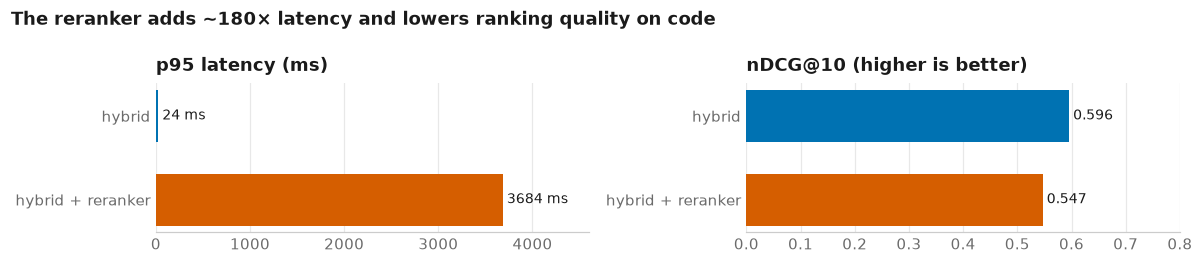

In [5]:
lat = [next(s for s in canonical if s["name"] == n) for n in
       ["AST + hybrid (RRF)", "AST + hybrid + reranker"]]
names = ["hybrid", "hybrid + reranker"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 2.4))
barh(ax1, names, [s["p95_ms"] for s in lat], colors=[BLUE, VERMILLION],
     title="p95 latency (ms)", fmt="{:.0f} ms", xmax=max(s["p95_ms"] for s in lat) * 1.25)
barh(ax2, names, [s["ndcg@10"] for s in lat], colors=[BLUE, VERMILLION],
     title="nDCG@10 (higher is better)", xmax=0.8)
fig.suptitle("The reranker adds ~180× latency and lowers ranking quality on code",
             color=INK, fontweight="bold", x=0.01, ha="left")
fig.tight_layout(); plt.show()

The reranker takes p95 from **14 ms → 2589 ms** while *lowering* R@5 (0.714 → 0.631),
MRR and nDCG versus plain hybrid. The `prefer_implementation` lever beats it for free.
So the ablation ships the reranker **disabled** (`RERANK_ENABLED=false`) and the table
is the evidence — exactly the arbitration descope §3 promised.

## Embedder decision — MiniLM vs BGE-M3 (cahier §6.3)

BGE-M3 is the usual quality reference for code retrieval, but it embeds at ~1.7 s/chunk
on this CPU against MiniLM's ~47 ms (**36×**, docs/evaluation.md D2), which breaks the
2-second incremental-reindex demo. The choice is arbitrated on Recall@10 / nDCG@10.

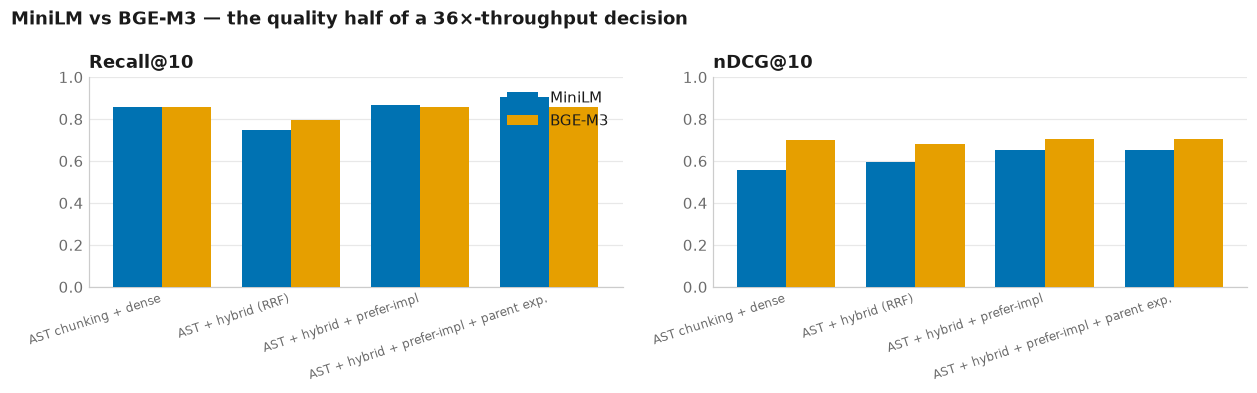

In [6]:
bge = by_tag("bge")
if not bge:
    print("BGE rows not present — run: uv run python evals/build_ablation_indexes.py --bge")
else:
    # Pair each BGE config with its MiniLM twin by name; color by embedder (entity).
    mini_by_name = {s["name"]: s for s in summaries
                    if s["embedder"] == "sentence-transformers/all-MiniLM-L6-v2"}
    pairs = [(s["name"], mini_by_name.get(s["name"]), s) for s in bge if s["name"] in mini_by_name]
    labels = [n for n, _, _ in pairs]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.6))
    x = range(len(pairs)); w = 0.38
    for ax, metric, title in ((ax1, "recall@10", "Recall@10"), (ax2, "ndcg@10", "nDCG@10")):
        ax.bar([i - w/2 for i in x], [m[metric] for _, m, _ in pairs], w, color=BLUE, label="MiniLM", zorder=3)
        ax.bar([i + w/2 for i in x], [b[metric] for _, _, b in pairs], w, color=ORANGE, label="BGE-M3", zorder=3)
        ax.set_xticks(list(x)); ax.set_xticklabels(labels, rotation=18, ha="right", fontsize=8)
        ax.set_ylim(0, 1.0); ax.set_title(title, color=INK, fontweight="bold", loc="left")
        for s_ in ("top", "right"): ax.spines[s_].set_visible(False)
        ax.yaxis.grid(True); ax.xaxis.grid(False); ax.tick_params(length=0)
    ax1.legend(frameon=False, loc="upper right")
    fig.suptitle("MiniLM vs BGE-M3 — the quality half of a 36×-throughput decision",
                 color=INK, fontweight="bold", x=0.01, ha="left")
    fig.tight_layout(); plt.show()
    frame(bge)[["recall@5", "recall@10", "mrr", "ndcg@10", "p95_ms"]]

## Conclusion — the frozen configuration

- **Embedder:** see the decision recorded in `docs/evaluation.md` (D4) and frozen in
  `config.py` — arbitrated on the numbers above, weighed against the 36× reindex cost.
- **Retrieval:** AST chunking · hybrid dense+BM25 with RRF · `prefer_implementation`
  demotion · parent-document expansion under a token budget.
- **Reranker:** built and measured, **shipped disabled** — the table is why.

Best measured configuration (MiniLM): **Recall@10 = 0.905, nDCG@10 = 0.652**, up from
the D3 exact-id baseline of 0.400.